# Крос-сценарна валідація fast-flux: логістична регресія, ізоляційний ліс та гібридна (каскадна) модель

| Параметр | Логістична регресія (LR) | Ізоляційний ліс (IF) | Гібридна (каскадна) модель (LR -> IF) |
|---|---|---|---|
| Трафік для навчання | Легітимний + fast-flux | Лише легітимний | Легітимний + fast-flux |
| Мітки | Так | Ні | Так (LR) / Ні (IF) |
| Тренувальні дані | Botnet-54 | Botnet-54 | Botnet-54 |
| Тестові дані | Botnet-46 | Botnet-46 | Botnet-46 |
| Оцінка | Accuracy / Precision / Recall / F1 / ROC-AUC | Accuracy / Precision / Recall / F1 / ROC-AUC | Accuracy / Precision / Recall / F1 / ROC-AUC |


In [1]:
# початковий момент для підрахунку часу виконання ноутбука
import time
_notebook_start = time.perf_counter()

import pandas as pd # обробка табличних даних
import numpy as np # векторні обчислення та операції з масивами
import matplotlib.pyplot as plt  # побудова графіків
%matplotlib inline            
# вбудоване відображення графіків

import warnings
warnings.filterwarnings('ignore')  # ігнорування помилок для чистого виводу результатів обчислень у комірках

from sklearn.linear_model import LogisticRegression # логістична регресія
from sklearn.ensemble import IsolationForest # ізоляційний ліс

from sklearn.preprocessing import StandardScaler # передобробка (нормалізація (x - mean) / std)

# підбір гіберпараметрів для логістичної регресії
from sklearn.model_selection import (
    KFold, # k-блокова крос-валідація
    cross_validate, # крос-валідація з кількома метриками одночасно
    learning_curve, # крива навчання (оцінка розміру вибірки та якості)
    validation_curve # валідаційна крива (оцінка значення гіперпараметра та якості)
)

# оцінка якості та візуалізація
from sklearn.metrics import (
    accuracy_score, # метрика accuracy: (TP + TN) / (TP + TN + FP + FN)
    precision_score, # метрика precision: TP / (TP + FP)
    recall_score, # метрика recall: TP / (TP + FN)
    f1_score, # метрика F1: (2 * precision * recall) / (precision + recall)
    roc_auc_score, # площа під ROC-кривою
    classification_report, # зведений звіт по класах
    ConfusionMatrixDisplay, # матриця невідповідностей
    RocCurveDisplay, # візуалізація ROC-крива
    precision_recall_curve # крива precision-recall (необхідна для вибору порогу ізоляційного лісу)
)

## 1. Завантаження підготовлених наборів даних

In [2]:
# CTU-Malware-Capture-Botnet-54 використовується для навчання і містить обидва класи
# CTU-Malware-Capture-Botnet-46 використовується для тестування
df_train = pd.read_csv('ff_agg_botnet54.csv')
df_test = pd.read_csv('ff_agg_botnet46.csv')

# виводимо статистику щодо розміру датасету та розподілу класів
print('CTU-Malware-Capture-Botnet-54 (TRAIN-дані)')
print(f'  {df_train.shape[0]:,} домен-вікон * {df_train.shape[1]} стовпців')
vc54 = df_train['label'].value_counts()
print(f'  Легітимні: {vc54.get(0.0,0):,}  Fast-flux: {vc54.get(1.0,0):,}')

print()
print('CTU-Malware-Capture-Botnet-46 (TEST-дані)')
print(f'  {df_test.shape[0]:,} домен-вікон * {df_test.shape[1]} стовпців')
vc46 = df_test['label'].value_counts()
print(f'  Легітимні: {vc46.get(0.0,0):,}  Fast-flux: {vc46.get(1.0,0):,}')


CTU-Malware-Capture-Botnet-54 (TRAIN-дані)
  2,323 домен-вікон * 26 стовпців
  Легітимні: 651  Fast-flux: 1,672

CTU-Malware-Capture-Botnet-46 (TEST-дані)
  584 домен-вікон * 26 стовпців
  Легітимні: 551  Fast-flux: 33


In [3]:
# узгодження стовпців між тренувальним і тестовим наборами даних 
# видалення зайвих стовпців у test та додавання відсутніх в test стовпців зі значенням 0)
feat_train = [c for c in df_train.columns if c != 'label']
feat_test  = [c for c in df_test.columns  if c != 'label']

for col in set(feat_train) - set(feat_test):
    df_test[col] = 0 # якщо ознака відсутня, то стовпець заповнюється нулями
df_test.drop(columns=list(set(feat_test) - set(feat_train)),
             inplace=True, errors='ignore') # видалення зайвих стовпців
df_test = df_test[df_train.columns] # вирівнювання порядку стовпців

# визначення стовпців, які не потребують масштабування
binary_pfx = ('has_','is_','uses_','frac_')
skip_scale = {'label'} | {c for c in df_train.columns
                           if any(c.startswith(p) for p in binary_pfx)}
scale_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns
              if c not in skip_scale]

# стандартизація ознак: (x - mean) / std
# метод fit() застосовується виключно для тренувальних даних для уникнення їх витоку та поширення на тестові дані
scaler = StandardScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols]) # навчання та перетворення
df_test[scale_cols]  = scaler.transform(df_test[scale_cols]) # перетворення

# формування матриці ознак X і векторів міток y для навчання та тестування
FEATURES = [c for c in df_train.columns if c != 'label']
X_train = df_train[FEATURES]; y_train = df_train['label']
X_test  = df_test[FEATURES]; y_test  = df_test['label']

print(f'X_train {X_train.shape},  X_test {X_test.shape}')
print(f'Ознак: {len(FEATURES)}')
print(f'Train: {int((y_train==1).sum())} fast-flux, {int((y_train==0).sum())} легітимні')
print(f'Test: {int((y_test==1).sum())} fast-flux, {int((y_test==0).sum())} легітимні')
print(f'Дисбаланс у test: {(y_test==0).sum()/(y_test==1).sum():.1f}:1')

X_train (2323, 25),  X_test (584, 25)
Ознак: 25
Train: 1672 fast-flux, 651 легітимні
Test: 33 fast-flux, 551 легітимні
Дисбаланс у test: 16.7:1


## 2. Логістична регресія

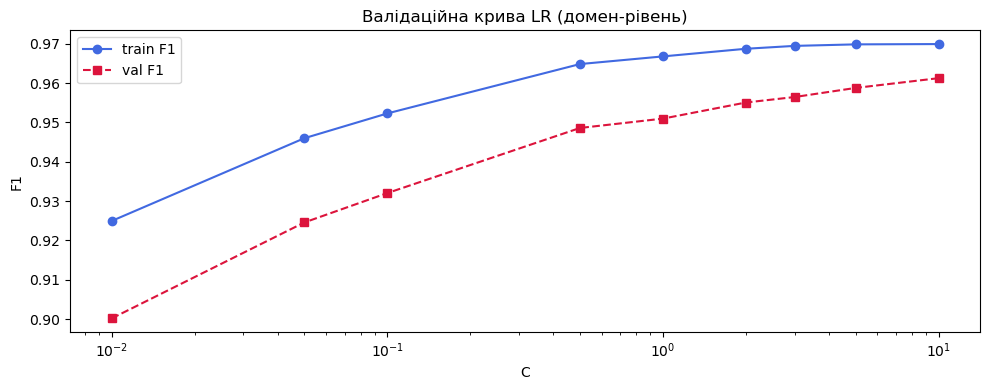

Оптимальний C = 10


In [4]:
# підбір гіперпараметра регуляризації C для логістичної регресії
# penalty='l2'
# solver='liblinear'
# class_weight='balanced'
# max_iter=5000
clf_vc = LogisticRegression(penalty='l2', solver='liblinear',
                             class_weight='balanced', max_iter=5000, random_state=42)

# діапазон C: логарифмічна шкала від 0.01 до 10
param_range = [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 5, 10]

# validation curve для кожного значення C виконує 5-блокову крос-валідацію та повертає масиви train/val scores
tr_sc, val_sc = validation_curve(
    clf_vc, X_train, y_train, param_name='C',
    param_range=param_range, scoring='f1',
    cv=KFold(5, shuffle=False)
)

# виведення графіку 
plt.figure(figsize=(10,4))
plt.plot(param_range, tr_sc.mean(axis=1),  'o-',  label='train F1', color='royalblue')
plt.plot(param_range, val_sc.mean(axis=1), 's--', label='val F1', color='crimson')
plt.xscale('log')
plt.xlabel('C'); plt.ylabel('F1')
plt.title('Валідаційна крива LR (домен-рівень)')
plt.legend(); plt.tight_layout(); plt.show()

# виведення оптимального значення параметра С
best_C = param_range[int(np.argmax(val_sc.mean(axis=1)))]
print(f'Оптимальний C = {best_C}')

In [5]:
# навчання моделі на повному тренувальному наборі із С = 10
clf_lr = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    C=best_C, # C = 10
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# вимірювання часу навчання моделі логістичної регресії (лише метод fit() без validation_curve)
_t0 = time.perf_counter()
clf_lr.fit(X_train, y_train)  # навчання на Botnet-54
t_lr_train = time.perf_counter() - _t0

# вимірювання часу передбачення моделлю логістичної регресії (predict() та predict_proba())
_t0 = time.perf_counter()
y_pred_lr = clf_lr.predict(X_test) # бінарні мітки для метрик: 0 або 1
y_prob_lr = clf_lr.predict_proba(X_test)[:,1] # ймовірність класу fast-flux (для ROC-AUC)
t_lr_infer = time.perf_counter() - _t0

print(f'LR навчання:     {t_lr_train:.3f} с')
print(f'LR передбачення: {t_lr_infer:.4f} с')
print()

# виведення метрик точності
print('Логістична регресія')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr, zero_division=0):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr, zero_division=0):.4f}')
print(f'F1: {f1_score(y_test, y_pred_lr, zero_division=0):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print()

''' Детальний звіт: precision, recall, f1 по кожному класу
print(classification_report(y_test, y_pred_lr,
      target_names=['Легітимні','Fast-Flux'], zero_division=0))'''

# виведення метрик ефективності та середнього часу передбачення об'єкта
from sklearn.metrics import confusion_matrix as _cm
_tn_lr, _fp_lr, _fn_lr, _tp_lr = _cm(y_test, y_pred_lr).ravel()
tpr_lr  = _tp_lr / (_tp_lr + _fn_lr) # TPR = TP / (TP + FN)
fpr_lr  = _fp_lr / (_fp_lr + _tn_lr) # FPR = FP / (FP + TN)
avg_t_lr = t_lr_infer / len(X_test) # T/N - середній час на об'єкт (с)
print(f'Середній час передбачення (T/N): {avg_t_lr*1e6:.4f} мкс/об')
print(f'TPR (True Positive Rate): {tpr_lr:.4f}')
print(f'FPR (False Positive Rate): {fpr_lr:.4f}')


LR навчання:     0.029 с
LR передбачення: 0.0042 с

Логістична регресія
Accuracy: 0.7705
Precision: 0.1902
Recall: 0.9394
F1: 0.3163
ROC-AUC: 0.9390

Середній час передбачення (T/N): 7.1841 мкс/об
TPR (True Positive Rate): 0.9394
FPR (False Positive Rate): 0.2396


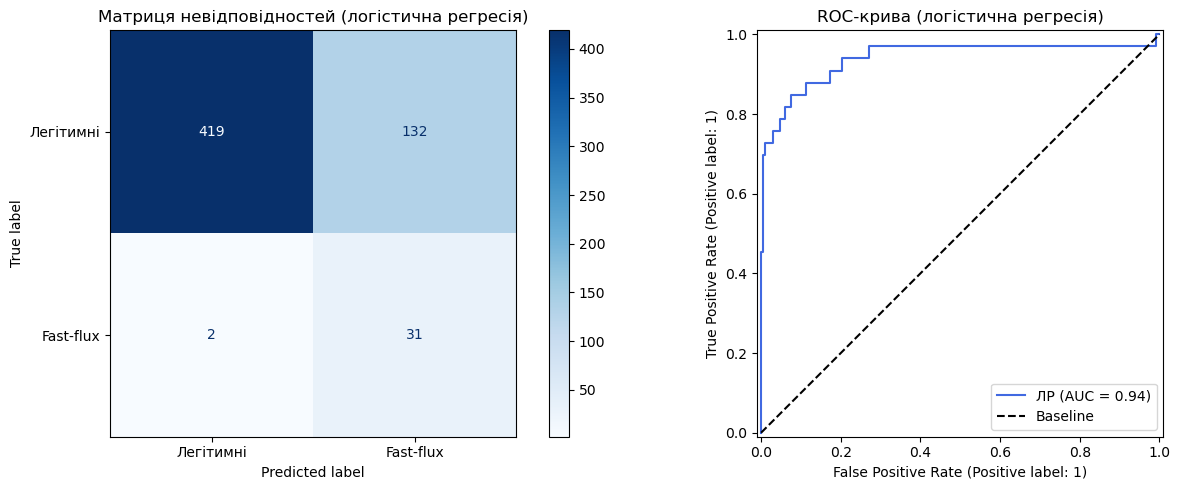

In [6]:
# матриця невідповідностей та ROC-крива
fig, axes = plt.subplots(1,2, figsize=(14,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Легітимні','Fast-flux'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Матриця невідповідностей (логістична регресія)')
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1], name='ЛР', color='royalblue')
axes[1].plot([0,1],[0,1],'k--', label='Baseline'); axes[1].legend()
axes[1].set_title('ROC-крива (логістична регресія)')
plt.tight_layout(); plt.show()

Топ-10 fast-flux ознак:
        feature      coef   odds_ratio
 frac_a_queries 15.311515 4.463816e+06
n_unique_cnames  1.170756 3.224431e+00
       ttl_mean  1.143101 3.136478e+00
        ttl_std  0.654139 1.923487e+00
        ttl_min  0.610388 1.841145e+00
      n_queries  0.528454 1.696308e+00
      n_dst_ips  0.484021 1.622585e+00
  ip_churn_rate  0.440066 1.552809e+00
    qry_entropy  0.312188 1.366412e+00
   n_unique_ips  0.128519 1.137143e+00

Топ-10 легітимних ознак:
      feature      coef  odds_ratio
nxdomain_rate -0.408413    0.664705
  ttl_entropy -0.452685    0.635918
    has_cname -0.700091    0.496540
 qry_name_len -0.700370    0.496402
   query_freq -0.735480    0.479275
n_unique_asns -0.799188    0.449694
    obs_hours -0.870549    0.418721
    qry_depth -1.504134    0.222210
      ttl_max -1.984520    0.137447
    n_src_ips -2.213299    0.109339


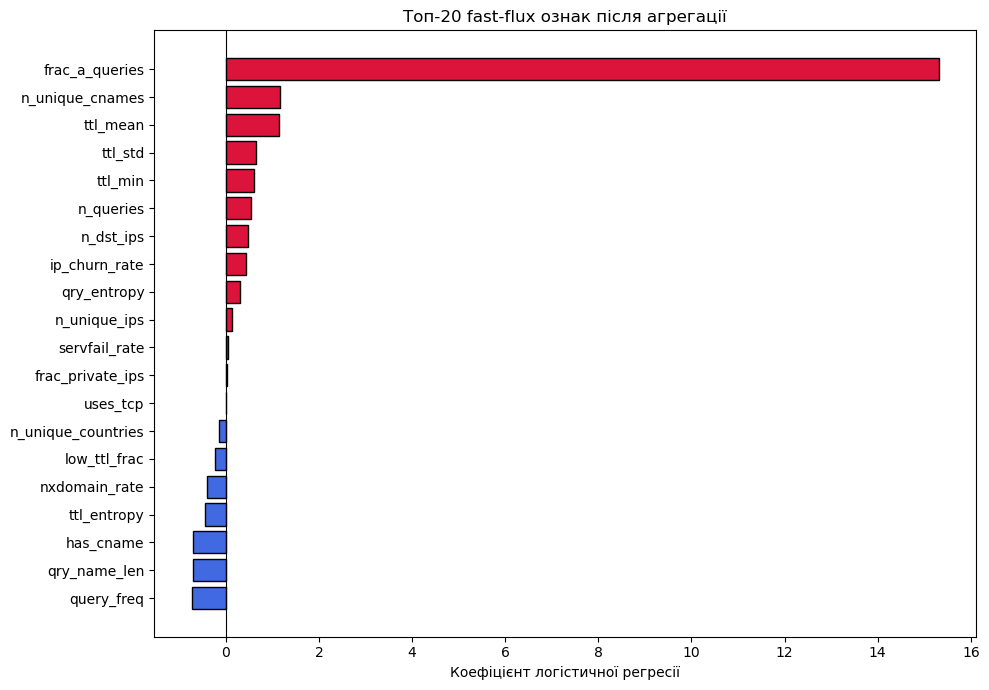

In [7]:
# аналіз коефіцієнтів, що впливають на рішення моделі логістичної регресії
coef_df = pd.DataFrame({
    'feature':    FEATURES,
    'coef':       clf_lr.coef_[0],
    'odds_ratio': np.exp(clf_lr.coef_[0])   
    # exp(coef) вказує, у скільки разів зростає шанс fast-flux при збільшенні ознаки на 1 std
}).sort_values('coef', ascending=False).reset_index(drop=True)

print('Топ-10 fast-flux ознак:') # найбільші позитивні коефіцієнти
print(coef_df.head(10)[['feature','coef','odds_ratio']].to_string(index=False))
print()
print('Топ-10 легітимних ознак:') # найбільші від'ємні коефіцієнти
print(coef_df.tail(10)[['feature','coef','odds_ratio']].to_string(index=False))

# гістограма для топ-20 ознак:
# червоний - fast-flux; синій - легітимні
colors = ['crimson' if c > 0 else 'royalblue' for c in coef_df.head(20)['coef']]
plt.figure(figsize=(10,7))
plt.barh(coef_df.head(20)['feature'], coef_df.head(20)['coef'],
         color=colors, edgecolor='black')
plt.axvline(0, color='black', lw=0.8)  # нульова лінія - межа між класами
plt.xlabel('Коефіцієнт логістичної регресії')
plt.title('Топ-20 fast-flux ознак після агрегації')
plt.gca().invert_yaxis() # найважливіша ознака буде згори
plt.tight_layout(); plt.show()


## 3. Ізоляційний ліс

In [8]:
# для тренування обираємо лише легітимні записи з тренувального набору (Botnet-54)
X_train_if = X_train[y_train == 0]
print(f'IF train: {X_train_if.shape[0]:,} нормальних домен-вікон')
print(f'IF test: {X_test.shape[0]:,} домен-вікон (Botnet-46, обидва класи)')

# задаємо точне значення з розподілу тестового набору (y_test.mean())
contamination = float(y_test.mean())
print(f'Частка fast-flux у test: {contamination:.3f}')

# гіперпараметри моделі
if_model = IsolationForest(
    n_estimators=500, # кількість дерев ізоляції
    # очікувана частка викидів
    contamination=contamination,
    #contamination=0.428,
    max_samples=256, # розмір підвибірки для побудови дерев
    max_features=0.8, # частка випадкових ознак для побудови дерев
    random_state=42,
    n_jobs=-1
)

# вимірювання часу навчання ізоляційного лісу (лише метод fit() на легітимних даних)
_t0 = time.perf_counter()
if_model.fit(X_train_if)  # навчання виключно на легітимних даних Botnet-54
t_if_train = time.perf_counter() - _t0

print(f'IF навчання: {t_if_train:.3f} с')

IF train: 651 нормальних домен-вікон
IF test: 584 домен-вікон (Botnet-46, обидва класи)
Частка fast-flux у test: 0.057
IF навчання: 1.334 с


In [9]:
# передбачення ізоляційного лісу на тестовому наборі (Botnet-46)
# при вимірюванні часу передбачення ізоляційним лісом враховуємо (predict() та score_samples()),
# бінарні мітки для метрик та оцінки для ROC-AUC і підбору порогу
_t0 = time.perf_counter()
if_preds_raw = if_model.predict(X_test)
if_scores = -if_model.score_samples(X_test)  # інвертуємо: вище = аномальніше
t_if_infer = time.perf_counter() - _t0

# перетворення виходу моделі у бінарні мітки
# якщо predict() повертає -1, це аномалія, а якщо 1 = легітимний трафік
# конвертуємо його до формату: 1 = fast-flux, 0 = легітимний
if_labels = (if_preds_raw == -1).astype(int)

print(f'IF передбачення: {t_if_infer:.4f} с')
print()

# розрахунок метрик точності
print('Ізоляційний ліс')
print(f'Accuracy  {accuracy_score(y_test, if_labels):.4f}')
print(f'Precision: {precision_score(y_test, if_labels, zero_division=0):.4f}')
print(f'Recall: {recall_score(y_test, if_labels, zero_division=0):.4f}')
print(f'F1: {f1_score(y_test, if_labels, zero_division=0):.4f}')
# показник ROC-AUC розраховується незалежно від порогу рішення
print(f'ROC-AUC: {roc_auc_score(y_test, if_scores):.4f}')
print()
print(classification_report(y_test, if_labels,
      target_names=['Легітимні','Fast-flux'], zero_division=0))

# розрахунок метрик ефективності та середнього часу передбачення
_tn_if, _fp_if, _fn_if, _tp_if = _cm(y_test, if_labels).ravel()
tpr_if  = _tp_if / (_tp_if + _fn_if) # TPR = TP / (TP + FN)
fpr_if  = _fp_if / (_fp_if + _tn_if) # FPR = FP / (FP + TN)
avg_t_if = t_if_infer / len(X_test) # T/N - середній час на об'єкт (с)
print(f'Середній час передбачення (T/N): {avg_t_if*1e6:.4f} мкс/об')
print(f'TPR (True Positive Rate)  : {tpr_if:.4f}')
print(f'FPR (False Positive Rate) : {fpr_if:.4f}')

IF передбачення: 0.2267 с

Ізоляційний ліс
Accuracy  0.8955
Precision: 0.1316
Recall: 0.1515
F1: 0.1408
ROC-AUC: 0.8105

              precision    recall  f1-score   support

   Легітимні       0.95      0.94      0.94       551
   Fast-flux       0.13      0.15      0.14        33

    accuracy                           0.90       584
   macro avg       0.54      0.55      0.54       584
weighted avg       0.90      0.90      0.90       584

Середній час передбачення (T/N): 388.1151 мкс/об
TPR (True Positive Rate)  : 0.1515
FPR (False Positive Rate) : 0.0599


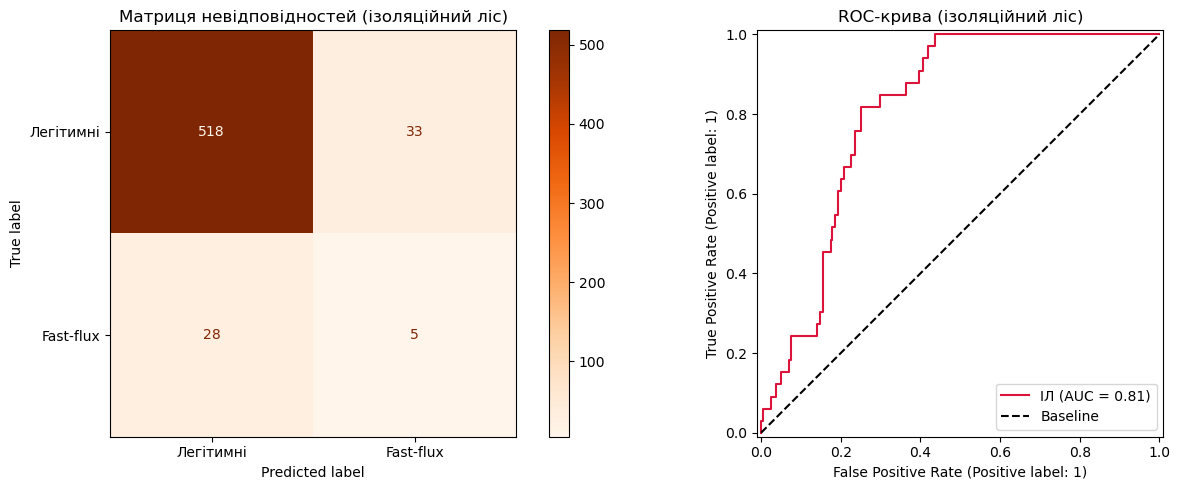

In [10]:
# виведення матриці невідповідностей та ROC-кривої
fig, axes = plt.subplots(1,2, figsize=(14,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, if_labels, display_labels=['Легітимні','Fast-flux'],
    cmap='Oranges', ax=axes[0])
axes[0].set_title('Матриця невідповідностей (ізоляційний ліс)')
RocCurveDisplay.from_predictions(y_test, if_scores, ax=axes[1], name='ІЛ', color='crimson')
axes[1].plot([0,1],[0,1],'k--', label='Baseline'); axes[1].legend()
axes[1].set_title('ROC-крива (ізоляційний ліс)')
plt.tight_layout(); plt.show()


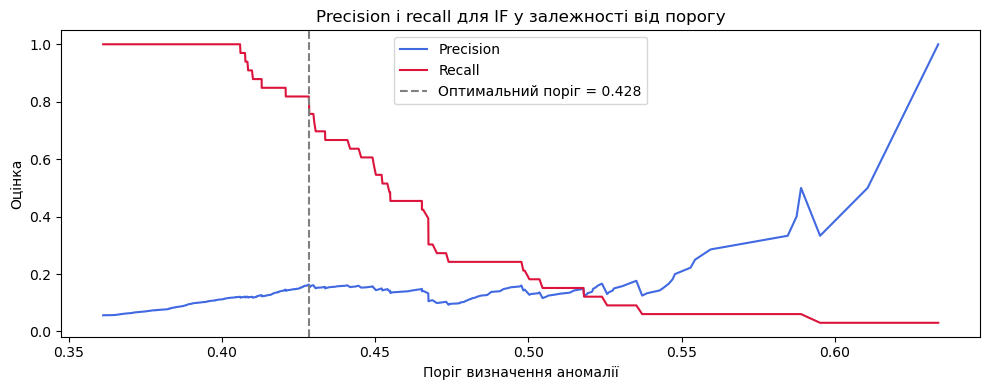

При порозі 0.428:
Recall : 0.8182
Precision : 0.1636
F1 : 0.2727
Accuracy : 0.7534


In [11]:
# визначення оптимального порогу аномальності замість використання параметра contamination

# precision_recall_curve повертає метрики  precision і recall для всіх можливих порогів
precs_if, recs_if, thrs_if = precision_recall_curve(y_test, if_scores)

# обчислюємо показник F1 для кожного порогу: F1 = 2 * P * R / (P + R)
# виключаємо останній елемент через відсутність відповідного порогу та додаємо 1^(-9) для захисту від ділення на нуль
f1s_if = 2*precs_if[:-1]*recs_if[:-1] / (precs_if[:-1]+recs_if[:-1]+1e-9) 

# визначаємо поріг із максимальним значенням показника F1
best_thr_if = thrs_if[np.argmax(f1s_if)]

# побудова графіка
plt.figure(figsize=(10,4))
plt.plot(thrs_if, precs_if[:-1], label='Precision', color='royalblue')
plt.plot(thrs_if, recs_if[:-1],  label='Recall', color='crimson')
plt.axvline(best_thr_if, linestyle='--', color='gray',
            label=f'Оптимальний поріг = {best_thr_if:.3f}')
plt.xlabel('Поріг визначення аномалії')
plt.ylabel('Оцінка')
plt.title('Precision і recall для IF у залежності від порогу')
plt.legend(); plt.tight_layout(); plt.show()

# оцінка метрик при оптимальному порозі
y_pred_opt_if = (if_scores >= best_thr_if).astype(int)  # 1 якщо оцінка >= порогу
print(f'При порозі {best_thr_if:.3f}:')
print(f'Recall : {recall_score(y_test, y_pred_opt_if, zero_division=0):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_opt_if, zero_division=0):.4f}')
print(f'F1 : {f1_score(y_test, y_pred_opt_if, zero_division=0):.4f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_opt_if):.4f}')
 # справжні мітки для 163 підозрілих

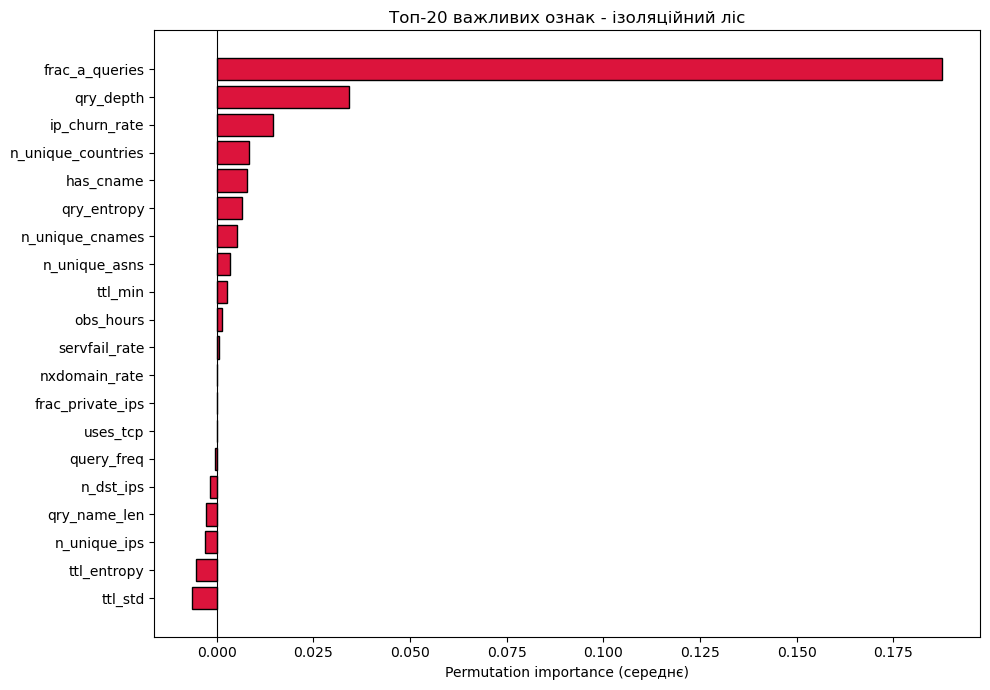

In [12]:
# визначаємо важливість ознак ізоляційного лісу через permutation_importance
from sklearn.inspection import permutation_importance

# обчислення ROC-AUC через оцінки аномальності
def if_roc_scorer(estimator, X, y):
    scores = -estimator.score_samples(X) # оцінка аномальності (чим вище значення, тим аномальніше)
    return roc_auc_score(y, scores) # порівняння зі справжніми мітками

# для кожної з 25 ознак виконуємо перемішування та вимірюємо зміну ROC-AUC
pi = permutation_importance(
    if_model, X_test, y_test, # тестовий набір з мітками
    scoring=if_roc_scorer,
)

# формування рейтингу ознак за середнім падінням показника ROC-AUC
pi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': pi.importances_mean # середнє падіння ROC-AUC при перемішуванні
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10,7))
plt.barh(pi_df['feature'], pi_df['importance'],
         color='crimson', edgecolor='black')
plt.xlabel('Permutation importance (середнє)')
plt.title('Топ-20 важливих ознак - ізоляційний ліс')
plt.gca().invert_yaxis() # найважливіша ознака буде згори
plt.axvline(0, color='black', lw=0.8)  # нульова лінія - межа між класами
plt.tight_layout(); plt.show()


## 4. Порівняння логістичної регресії та ізоляційного лісу


Train: Botnet-54 (2,323 домен-вікон)
Test: Botnet-46 (584 домен-вікон)
           Логістична регресія  Ізоляційний ліс
Метрика                                        
Accuracy                0.7705           0.8955
Precision               0.1902           0.1316
Recall                  0.9394           0.1515
F1                      0.3163           0.1408
ROC-AUC                 0.9390           0.8105


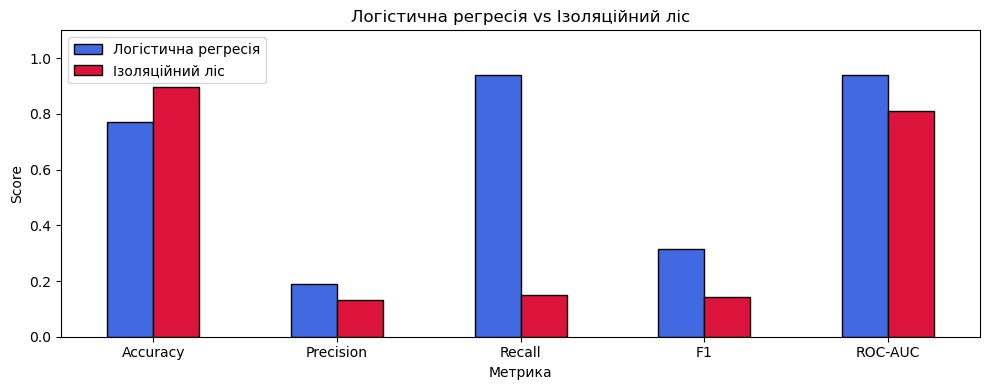


Час виконання (базові моделі):
                      Логістична регресія  Ізоляційний ліс
Метрика                                                   
Час навчання (с)                   0.0290           1.3340
Час передбачення (с)               0.0042           0.2267


In [13]:
# зведена таблиця порівняння моделей логістичної регресії та ізоляційного лісу
print(f'Train: Botnet-54 ({len(df_train):,} домен-вікон)')
print(f'Test: Botnet-46 ({len(df_test):,} домен-вікон)')

comp = pd.DataFrame({
    'Метрика': ['Accuracy','Precision','Recall','F1','ROC-AUC'],
    'Логістична регресія': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0),
        roc_auc_score(y_test, y_prob_lr),
    ],
    'Ізоляційний ліс': [
        accuracy_score(y_test, if_labels),
        precision_score(y_test, if_labels, zero_division=0),
        recall_score(y_test, if_labels, zero_division=0),
        f1_score(y_test, if_labels, zero_division=0),
        roc_auc_score(y_test, if_scores),
    ],
}).set_index('Метрика')

print(comp.round(4).to_string())

comp.plot(kind='bar', figsize=(10,4), rot=0, edgecolor='black',
          color=['royalblue','crimson'])
plt.title('Логістична регресія vs Ізоляційний ліс')
plt.ylabel('Score'); plt.ylim(0,1.1)
plt.legend(); plt.tight_layout(); plt.show()

time_df_base = pd.DataFrame({
    'Метрика': ['Час навчання (с)', 'Час передбачення (с)'],
    'Логістична регресія': [round(t_lr_train, 3), round(t_lr_infer, 4)],
    'Ізоляційний ліс': [round(t_if_train, 3), round(t_if_infer, 4)],
}).set_index('Метрика')
print('\nЧас виконання (базові моделі):')
print(time_df_base.to_string())


## 5. Гібридна модель - каскад (LR -> IF)

Архітектура каскадної моделі:
1. **LR (перший етап)** - сканує весь тестовий набір. Домени, що отримали predict == 0 (легітимні), одразу відхиляються та не передаються далі.
2. **IF (другий етап)** - отримує лише домени, що LR позначила як fast-flux (predict == 1), і підтверджує (predict == -1) або спростовує це рішення (predict == 1) за оцінкою аномальності.

In [14]:
# обидві моделі (clf_lr і if_model) навчені у попередніх кроках
# вимірюємо час навчання гібридної моделі за формулою t_lr_train + t_if_train.
t_cascade_train = t_lr_train + t_if_train
print(f'Загальний час навчання гібридної моделі: {t_cascade_train:.3f} с')
print(f'LR навчання: {t_lr_train:.3f} с')
print(f'IF навчання: {t_if_train:.3f} с')
print()

# Крок 1: логістична регресія
_t0 = time.perf_counter()
lr_pred_all = clf_lr.predict(X_test) # передбачення логістичною регресією за всіма тестовими даними
lr_prob_all = clf_lr.predict_proba(X_test)[:,1] # розрахунок імовірності fast-flux для ROC
t_cascade_lr = time.perf_counter() - _t0

# булеві маски
flagged_mask = (lr_pred_all == 1) # якщо LR визначила домен як fast-flux, то передає на IF
clear_mask = ~flagged_mask # якщо LR визначила домен легітимним, присвоює мітку 0

y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

print(f'Крок 1 (LR): {flagged_mask.sum()} підозрілих -> передаємо до IF')
print(f'             {clear_mask.sum()} легітимних -> одразу відхилено')
# кількість переданих fast-flux до IF
ff_flagged = y_test_arr[flagged_mask].sum()
ff_total   = y_test_arr.sum()
print(f'             fast-flux у підозрілих: {int(ff_flagged)}/{int(ff_total)} ({ff_flagged/ff_total*100:.1f}%)')
# дисбаланс у підвибірці, що надходить до IF
legit_flagged = (~y_test_arr[flagged_mask].astype(bool)).sum()
print(f'             дисбаланс у підозрілих: {legit_flagged}:{int(ff_flagged)} '
      f'({legit_flagged/max(ff_flagged,1):.1f}:1)')
print()

# Крок 2: Ізоляційний ліс
# IF отримує для опрацювання підозрілу підмножину
X_flagged = X_test[flagged_mask]

_t0 = time.perf_counter()
if_pred_flagged = if_model.predict(X_flagged) # якщо IF також визначає домен як аномальний (-1), то отримуємо підтвердження fast-flux
if_score_flagged = -if_model.score_samples(X_flagged) # оцінка аномальності
t_cascade_if = time.perf_counter() - _t0

# IF підтверджує лише ті домени, які теж вважає аномаліями
# if_confirms = (if_pred_flagged == -1)  # якщо показник True, то обидві моделі визначають домен як зловмисний

# IF підтверджує домени з оцінкою аномальності >= оптимального порогу
CASCADE_THR = 0.428
if_confirms = (if_score_flagged >= CASCADE_THR)

print(f'Крок 2 (IF): з {flagged_mask.sum()} підозрілих IF підтвердив {if_confirms.sum()} як fast-flux')
print(f'             IF скасував {(~if_confirms).sum()} хибних спрацювань LR')
print()

# остаточна розмітка даних (1, якщо LR та IF визначили домен як зловмисний; 0 у інших випадках)
y_pred_cascade = np.zeros(len(X_test), dtype=int)
# заповнюємо тільки індекси, що задовольняють умові LR та IF
flagged_idx = np.where(flagged_mask)[0] # індекси підозрілих у X_test
confirmed_idx = flagged_idx[if_confirms] # скільки з них - підтверджені IF
y_pred_cascade[confirmed_idx] = 1

# визначаємо комбіновану оцінку для ROC-AUC за принципом добутку ймовірності LR на нормалізовану оціку IF аномальності
# нормалізація if_scores до [0,1]
if_scores_all = -if_model.score_samples(X_test)
if_norm = (if_scores_all - if_scores_all.min()) / (if_scores_all.max() - if_scores_all.min() + 1e-9)
# комбінована оцінка визначається як середнє геометричне LR-ймовірності та нормалізованої IF-оцінки
y_prob_cascade = np.sqrt(lr_prob_all * if_norm)

t_cascade_infer = t_cascade_lr + t_cascade_if
print(f'Крок 1 (LR передбачення): {t_cascade_lr:.4f} с')
print(f'Крок 2 (IF передбачення): {t_cascade_if:.4f} с  ({flagged_mask.sum()} записів)')
print(f'Загальний час передбачення гібридною моделлю: {t_cascade_infer:.4f} с')

Загальний час навчання гібридної моделі: 1.363 с
LR навчання: 0.029 с
IF навчання: 1.334 с

Крок 1 (LR): 163 підозрілих -> передаємо до IF
             421 легітимних -> одразу відхилено
             fast-flux у підозрілих: 31/33 (93.9%)
             дисбаланс у підозрілих: 132:31 (4.3:1)

Крок 2 (IF): з 163 підозрілих IF підтвердив 66 як fast-flux
             IF скасував 97 хибних спрацювань LR

Крок 1 (LR передбачення): 0.0058 с
Крок 2 (IF передбачення): 0.2065 с  (163 записів)
Загальний час передбачення гібридною моделлю: 0.2123 с


Гібридна (каскадна) модель
Accuracy: 0.9161
Precision: 0.3788
Recall: 0.7576
F1: 0.5051
ROC-AUC   : 0.9219

              precision    recall  f1-score   support

   Легітимні       0.98      0.93      0.95       551
   Fast-flux       0.38      0.76      0.51        33

    accuracy                           0.92       584
   macro avg       0.68      0.84      0.73       584
weighted avg       0.95      0.92      0.93       584



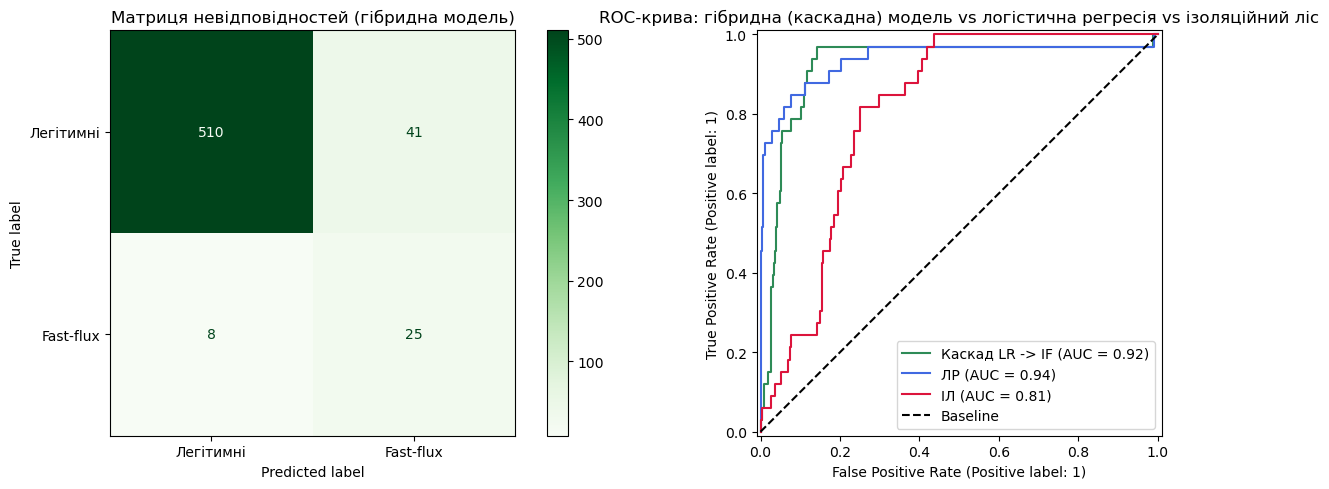

Середній час передбачення (T/N): 363.4962 мкс/об
TPR (True Positive Rate)  : 0.7576
FPR (False Positive Rate) : 0.0744


In [15]:
# метрики точності гібридної моделі
print('Гібридна (каскадна) модель')
print(f'Accuracy: {accuracy_score(y_test, y_pred_cascade):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_cascade, zero_division=0):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_cascade, zero_division=0):.4f}')
print(f'F1: {f1_score(y_test, y_pred_cascade, zero_division=0):.4f}')
# визначення ROC-AUC за комбінованим показником score: sqrt(LR_prob * IF_norm)
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob_cascade):.4f}')
print()
print(classification_report(y_test, y_pred_cascade,
      target_names=['Легітимні','Fast-flux'], zero_division=0))

# виведення матриці невідповідностей та ROC-кривої
fig, axes = plt.subplots(1,2, figsize=(14,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cascade,
    display_labels=['Легітимні','Fast-flux'],
    cmap='Greens', ax=axes[0])
axes[0].set_title('Матриця невідповідностей (гібридна модель)')

# ROC-крива для усіх трьох моделей
RocCurveDisplay.from_predictions(y_test, y_prob_cascade, ax=axes[1], name='Каскад LR -> IF', color='seagreen')
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1], name='ЛР', color='royalblue')
RocCurveDisplay.from_predictions(y_test, if_scores, ax=axes[1], name='ІЛ', color='crimson')
axes[1].plot([0,1],[0,1],'k--', label='Baseline')
axes[1].legend()
axes[1].set_title('ROC-крива: гібридна (каскадна) модель vs логістична регресія vs ізоляційний ліс')
plt.tight_layout(); plt.show()

# додаткові метрики ефективності та продуктивності
_tn_cas, _fp_cas, _fn_cas, _tp_cas = _cm(y_test, y_pred_cascade).ravel()
tpr_cascade  = _tp_cas / (_tp_cas + _fn_cas) # TPR = TP / (TP + FN)
fpr_cascade  = _fp_cas / (_fp_cas + _tn_cas) # FPR = FP / (FP + TN)
avg_t_cascade = t_cascade_infer / len(X_test) # T/N - середній час на об'єкт (с)
print(f'Середній час передбачення (T/N): {avg_t_cascade*1e6:.4f} мкс/об')
print(f'TPR (True Positive Rate)  : {tpr_cascade:.4f}')
print(f'FPR (False Positive Rate) : {fpr_cascade:.4f}')


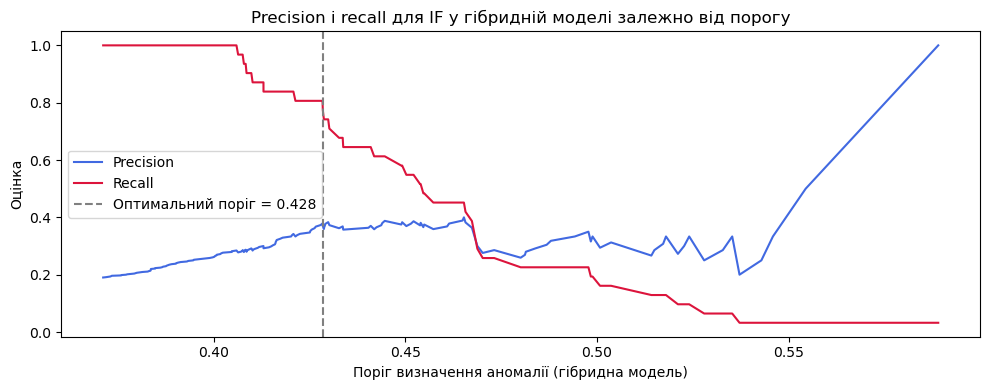

При порозі 0.428:
Recall:    0.7576
Precision: 0.3788
F1:        0.5051
Accuracy:  0.9161


In [16]:
# відновлення змінних
lr_pred_all = clf_lr.predict(X_test)
flagged_mask = (lr_pred_all == 1)
flagged_idx = np.where(flagged_mask)[0]
if_score_flagged = -if_model.score_samples(X_test[flagged_mask])

# визначення оптимального порогу аномальності IF у гібридній моделі
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
y_flagged_true = y_test_arr[flagged_mask]

# precision_recall_curve повертає метрики precision і recall для всіх можливих порогів
precs_if, recs_if, thrs_if = precision_recall_curve(y_flagged_true, if_score_flagged)

# обчислюємо показник F1 для кожного порогу: F1 = 2 * P * R / (P + R)
f1s_if = 2*precs_if[:-1]*recs_if[:-1] / (precs_if[:-1]+recs_if[:-1]+1e-9)

# визначаємо поріг із максимальним значенням показника F1
best_thr_if = thrs_if[np.argmax(f1s_if)]

# побудова графіка
plt.figure(figsize=(10,4))
plt.plot(thrs_if, precs_if[:-1], label='Precision', color='royalblue')
plt.plot(thrs_if, recs_if[:-1],  label='Recall', color='crimson')
plt.axvline(best_thr_if, linestyle='--', color='gray',
            label=f'Оптимальний поріг = {best_thr_if:.3f}')
plt.xlabel('Поріг визначення аномалії (гібридна модель)')
plt.ylabel('Оцінка')
plt.title('Precision і recall для IF у гібридній моделі залежно від порогу')
plt.legend(); plt.tight_layout(); plt.show()

# оцінка метрик при оптимальному порозі
y_pred_opt_if = np.zeros(len(X_test), dtype=int)                  # +
y_pred_opt_if[flagged_idx[if_score_flagged >= best_thr_if]] = 1   # ^ (if_scores >= best_thr_if).astype(int)

print(f'При порозі {best_thr_if:.3f}:')
print(f'Recall:    {recall_score(y_test, y_pred_opt_if, zero_division=0):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_opt_if, zero_division=0):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_opt_if, zero_division=0):.4f}')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_opt_if):.4f}')

## 6. Остаточне порівняння логістичної регресії, ізоляційного лісу та гібридної моделі


Train: Botnet-54 (2,323 домен-вікон)
Test: Botnet-46 (584 домен-вікон)

           Логістична регресія  Ізоляційний ліс  Гібридна модель
Метрика                                                         
Accuracy                0.7705           0.8955           0.9161
Precision               0.1902           0.1316           0.3788
Recall                  0.9394           0.1515           0.7576
F1                      0.3163           0.1408           0.5051
ROC-AUC                 0.9390           0.8105           0.9219


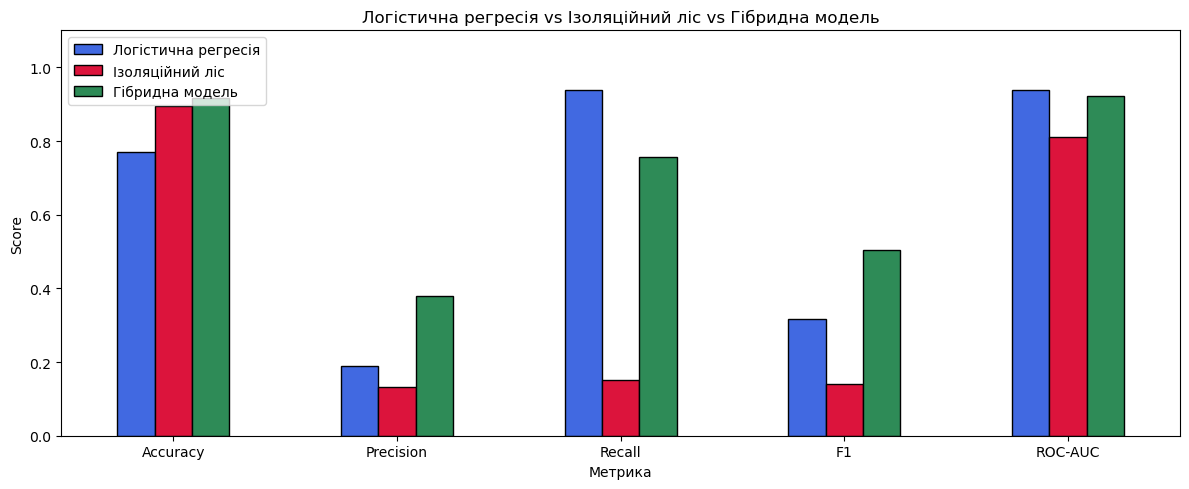


Час виконання:
                      Логістична регресія  Ізоляційний ліс  Гібридна модель
Метрика                                                                    
Час навчання (с)                   0.0290           1.3340           1.3630
Час передбачення (с)               0.0042           0.2267           0.2123

Загальний час виконання ноутбука: 29.93 с  (0.5 хв)


In [17]:
# розмір наборів даних
print(f'Train: Botnet-54 ({len(df_train):,} домен-вікон)')
print(f'Test: Botnet-46 ({len(df_test):,} домен-вікон)')
print()

comp_all = pd.DataFrame({
    'Метрика': ['Accuracy','Precision','Recall','F1','ROC-AUC'],
    'Логістична регресія': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0),
        roc_auc_score(y_test, y_prob_lr),
    ],
    'Ізоляційний ліс': [
        accuracy_score(y_test, if_labels),
        precision_score(y_test, if_labels, zero_division=0),
        recall_score(y_test, if_labels, zero_division=0),
        f1_score(y_test, if_labels, zero_division=0),
        roc_auc_score(y_test, if_scores),
    ],
    'Гібридна модель': [
        accuracy_score(y_test, y_pred_cascade),
        precision_score(y_test, y_pred_cascade, zero_division=0),
        recall_score(y_test, y_pred_cascade, zero_division=0),
        f1_score(y_test, y_pred_cascade, zero_division=0),
        roc_auc_score(y_test, y_prob_cascade),
    ],
}).set_index('Метрика')

print(comp_all.round(4).to_string())

# гістограма трьох моделей
comp_all.plot(kind='bar', figsize=(12,5), rot=0, edgecolor='black',
              color=['royalblue','crimson','seagreen'])
plt.title('Логістична регресія vs Ізоляційний ліс vs Гібридна модель')
plt.ylabel('Score'); plt.ylim(0,1.1)
plt.legend(); plt.tight_layout(); plt.show()

# зведена таблиця часу виконання
time_all = pd.DataFrame({
    'Метрика': ['Час навчання (с)', 'Час передбачення (с)'],
    'Логістична регресія': [round(t_lr_train, 3), round(t_lr_infer, 4)],
    'Ізоляційний ліс': [round(t_if_train, 3), round(t_if_infer, 4)],
    'Гібридна модель': [round(t_cascade_train, 3), round(t_cascade_infer, 4)],
}).set_index('Метрика')
print('\nЧас виконання:')
print(time_all.to_string())

# виведення виконання часу ноутбука
elapsed = time.perf_counter() - _notebook_start
print(f'\nЗагальний час виконання ноутбука: {elapsed:.2f} с  ({elapsed/60:.1f} хв)')


                                     Логістична регресія  Ізоляційний ліс  Гібридна модель
Показник                                                                                  
Середній час передбачення (мкс/об.)               7.1841         388.1151         363.4962
TPR - True Positive Rate                          0.9394           0.1515           0.7576
FPR - False Positive Rate                         0.2396           0.0599           0.0744


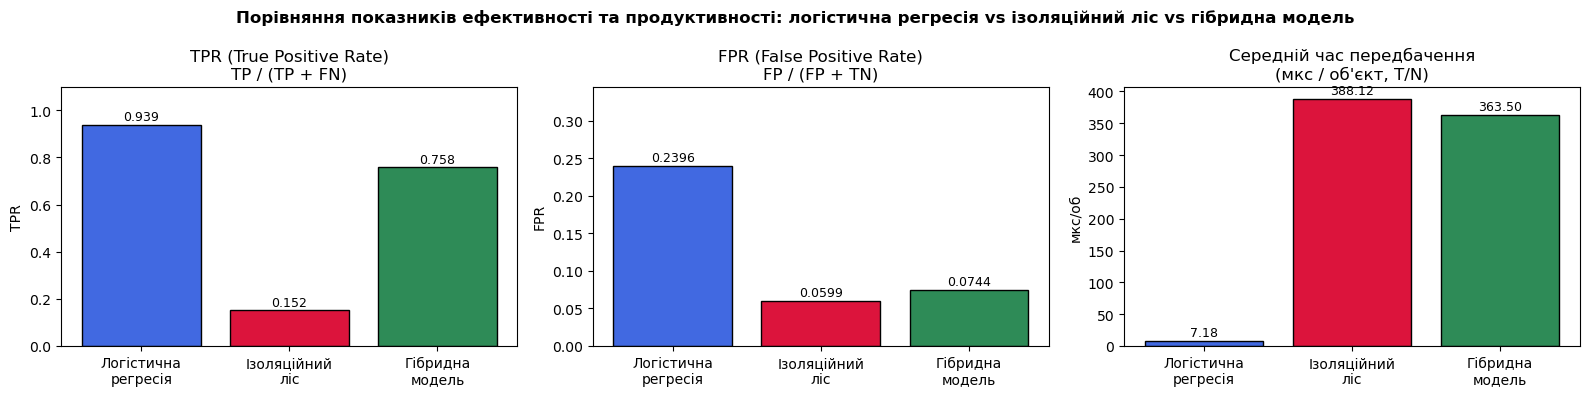

In [18]:
# зведена таблиця показників ефективності та продуктивності

perf_table = pd.DataFrame({
    'Показник': [
        'Середній час передбачення (мкс/об.)',
        'TPR - True Positive Rate',
        'FPR - False Positive Rate',
    ],
    'Логістична регресія': [
        round(avg_t_lr  * 1e6, 4),
        round(tpr_lr,  4),
        round(fpr_lr,  4),
    ],
    'Ізоляційний ліс': [
        round(avg_t_if  * 1e6, 4),
        round(tpr_if,  4),
        round(fpr_if,  4),
    ],
    'Гібридна модель': [
        round(avg_t_cascade * 1e6, 4),
        round(tpr_cascade, 4),
        round(fpr_cascade, 4),
    ],
}).set_index('Показник')

print(perf_table.to_string())

# графік TPR та FPR для трьох моделей
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models   = ['Логістична\nрегресія', 'Ізоляційний\nліс', 'Гібридна\nмодель']
tpr_vals = [tpr_lr, tpr_if, tpr_cascade]
fpr_vals = [fpr_lr, fpr_if, fpr_cascade]
avg_t_vals = [avg_t_lr*1e6, avg_t_if*1e6, avg_t_cascade*1e6]
colors   = ['royalblue', 'crimson', 'seagreen']

axes[0].bar(models, tpr_vals, color=colors, edgecolor='black')
axes[0].set_title('TPR (True Positive Rate)\nTP / (TP + FN)')
axes[0].set_ylabel('TPR'); axes[0].set_ylim(0, 1.1)
for ax0, v in zip(axes[0].patches, tpr_vals):
    axes[0].text(ax0.get_x() + ax0.get_width()/2, v + 0.02,
                 f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(models, fpr_vals, color=colors, edgecolor='black')
axes[1].set_title('FPR (False Positive Rate)\nFP / (FP + TN)')
axes[1].set_ylabel('FPR'); axes[1].set_ylim(0, max(fpr_vals)*1.4 + 0.01)
for ax1, v in zip(axes[1].patches, fpr_vals):
    axes[1].text(ax1.get_x() + ax1.get_width()/2, v + max(fpr_vals)*0.03,
                 f'{v:.4f}', ha='center', fontsize=9)

axes[2].bar(models, avg_t_vals, color=colors, edgecolor='black')
axes[2].set_title('Середній час передбачення\n(мкс / об\'єкт, T/N)')
axes[2].set_ylabel('мкс/об')
for ax2, v in zip(axes[2].patches, avg_t_vals):
    axes[2].text(ax2.get_x() + ax2.get_width()/2, v + max(avg_t_vals)*0.02,
                 f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Порівняння показників ефективності та продуктивності: логістична регресія vs ізоляційний ліс vs гібридна модель',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
